In [2]:
import pysmu
s=pysmu.Session()

In [266]:
s._close()

In [3]:
dev=s.devices[0]
print(dev)

serial 20322050544A4D39203130323930303 : fw 2.17 : hw F


In [4]:
dev.channels["A"].mode=pysmu.Mode.SVMI
dev.channels["B"].mode=pysmu.Mode.HI_Z

[5.0, 4.877641201019287, 4.522542476654053, 3.9694631099700928, 3.2725424766540527, 2.5, 1.7274575233459473, 1.0305368900299072, 0.47745752334594727, 0.12235870957374573, 0.0, 0.12235870957374573, 0.47745752334594727, 1.0305368900299072, 1.7274575233459473, 2.5, 3.2725424766540527, 3.9694631099700928, 4.522542476654053, 4.877641201019287, 5.0, 4.877641201019287, 4.522542476654053, 3.9694631099700928, 3.2725424766540527, 2.5, 1.7274575233459473, 1.0305368900299072, 0.47745752334594727, 0.12235870957374573, 0.0, 0.12235870957374573, 0.47745752334594727, 1.0305368900299072, 1.7274575233459473, 2.5, 3.2725424766540527, 3.9694631099700928, 4.522542476654053, 4.877641201019287, 5.0, 4.877641201019287, 4.522542476654053, 3.9694631099700928, 3.2725424766540527, 2.5, 1.7274575233459473, 1.0305368900299072, 0.47745752334594727, 0.12235870957374573, 0.0, 0.12235870957374573, 0.47745752334594727, 1.0305368900299072, 1.7274575233459473, 2.5, 3.2725424766540527, 3.9694631099700928, 4.522542476654053

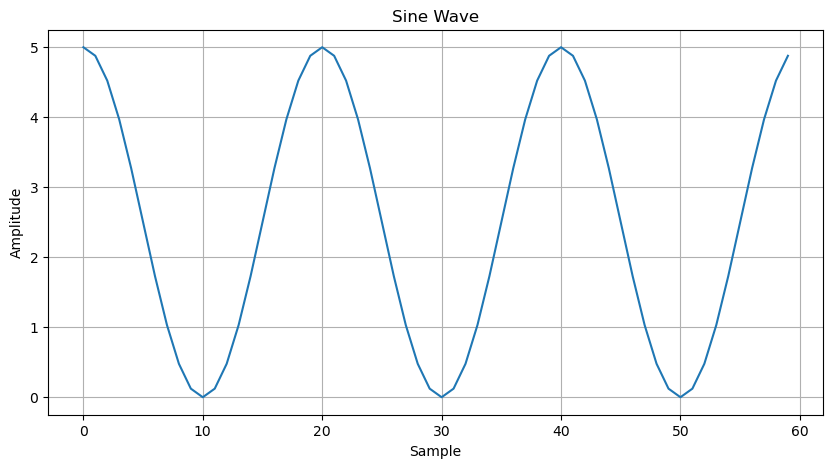

In [9]:
sig=pysmu.Signal()
p=20
sine_wave = sig.sine(samples=3*p, midpoint=0, peak=5, period=p, phase=0)
print(sine_wave)
import numpy as np
x=sine_wave
signal = x - np.mean(x)
N = len(signal)

spectrum = np.fft.rfft(signal)
freqs = np.fft.rfftfreq(N, d=1)  # cycles/sample

peak_idx = np.argmax(np.abs(spectrum[1:])) + 1
peak_freq = freqs[peak_idx]

print("Frequency =", peak_freq, "cycles/sample")
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(sine_wave)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Sine Wave')
plt.grid(True)
plt.show()

In [232]:
dev.channels["A"].write(sine_wave,-1)
s.start(10*p+100)

In [233]:
data = dev.read(100)
data= dev.read(10*p+100)
list1, list2, list3, list4 = [], [], [], []

# Loop through the items without unpacking them immediately
for item in data:
    # Check if the item is actually a tuple 
    if isinstance(item, tuple):
        # Now it is safe to unpack
        (a, b), (c, d) = item
        list1.append(a)
        list2.append(b)
        list3.append(c)
        list4.append(d)
    else:
        # If it hits the '...', it simply ignores it and moves on
        continue

print(list1)
print(list3)
print(len(list1))
print(len(list3))

[4.940493106842041, 4.680295944213867, 4.234992980957031, 3.608107805252075, 2.856252670288086, 2.105572462081909, 1.383237361907959, 0.7475823760032654, 0.29029929637908936, 0.06784355640411377, 0.057664304971694946, 0.3149643838405609, 0.7601889967918396, 1.3895797729492188, 2.152710199356079, 2.896108388900757, 3.6192264556884766, 4.255507946014404, 4.711381912231445, 4.931332111358643, 4.940414905548096, 4.680217742919922, 4.234836578369141, 3.608107805252075, 2.856252670288086, 2.1056506633758545, 1.3833940029144287, 0.7475041151046753, 0.2904558777809143, 0.0677652582526207, 0.057507701218128204, 0.31488609313964844, 0.7601107358932495, 1.3895797729492188, 2.1526317596435547, 2.8960301876068115, 3.619304895401001, 4.255429744720459, 4.711460113525391, 4.931410312652588, 4.940414905548096, 4.680295944213867, 4.234914779663086, 3.6079511642456055, 2.8561744689941406, 2.105572462081909, 1.3833156824111938, 0.7476606965065002, 0.29053419828414917, 0.0677652582526207, 0.05750770121812

In [6]:
def gain_phase(inp, out):
    x = np.asarray(inp, dtype=float)
    y = np.asarray(out, dtype=float)

    # Remove DC
    x = x - np.mean(x)
    y = y - np.mean(y)

    N = len(x)

    # FFT
    X = np.fft.rfft(x)
    Y = np.fft.rfft(y)

    # Ignore DC bin
    k = np.argmax(np.abs(X[1:])) + 1

    # Transfer function
    H = Y[k] / X[k]

    mag_linear = np.abs(H)
    mag_db = 20 * np.log10(mag_linear)

    phase_deg = np.angle(H, deg=True)

    freq_cycles_per_sample = k / N

    return {
        "frequency_cycles_per_sample": freq_cycles_per_sample,
        "magnitude_linear": mag_linear,
        "magnitude_db": mag_db,
        "phase_deg": phase_deg
    }

In [11]:
measurement_results = measure_gain_phase_at_freqs(s,dev, ps)

Measured 200 samples for period 20
Measured 400 samples for period 40
Measured 600 samples for period 60
Measured 800 samples for period 80
Measured 1000 samples for period 100
Measured 1200 samples for period 120
Measured 1400 samples for period 140
Measured 1600 samples for period 160
Measured 1800 samples for period 180
Measured 2000 samples for period 200
Measured 2200 samples for period 220
Measured 2400 samples for period 240
Measured 2600 samples for period 260
Measured 2800 samples for period 280
Measured 3000 samples for period 300
Measured 3200 samples for period 320
Measured 3400 samples for period 340
Measured 3600 samples for period 360
Measured 3800 samples for period 380
Measured 4000 samples for period 400
Measured 4200 samples for period 420
Measured 4400 samples for period 440
Measured 4600 samples for period 460
Measured 4800 samples for period 480


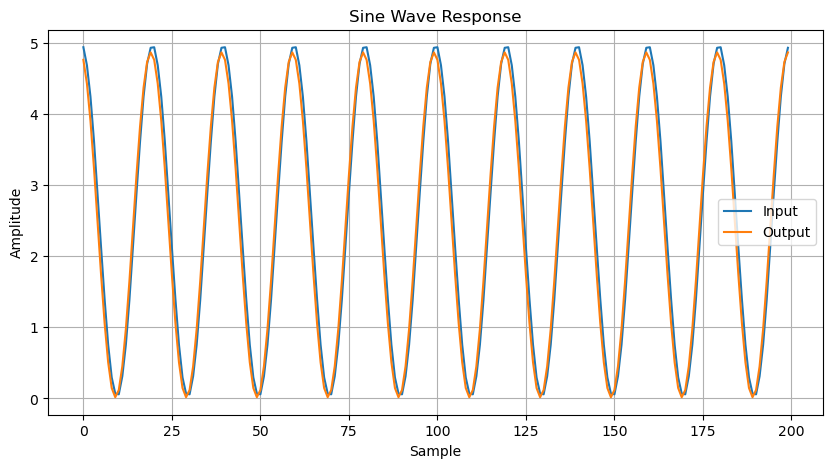

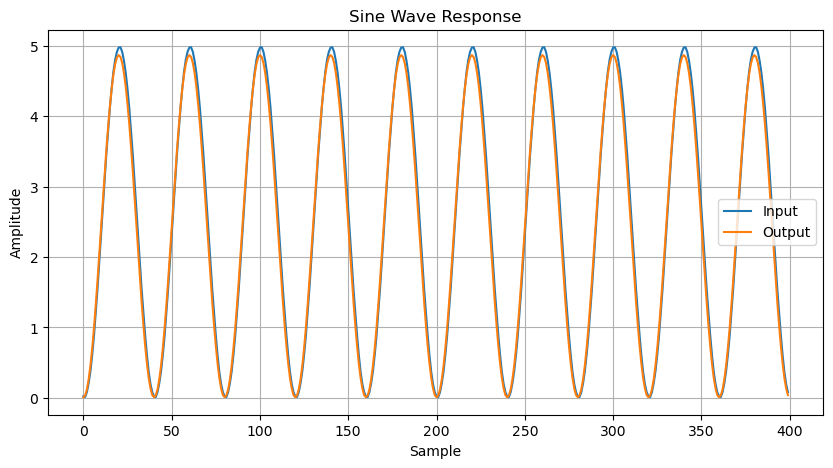

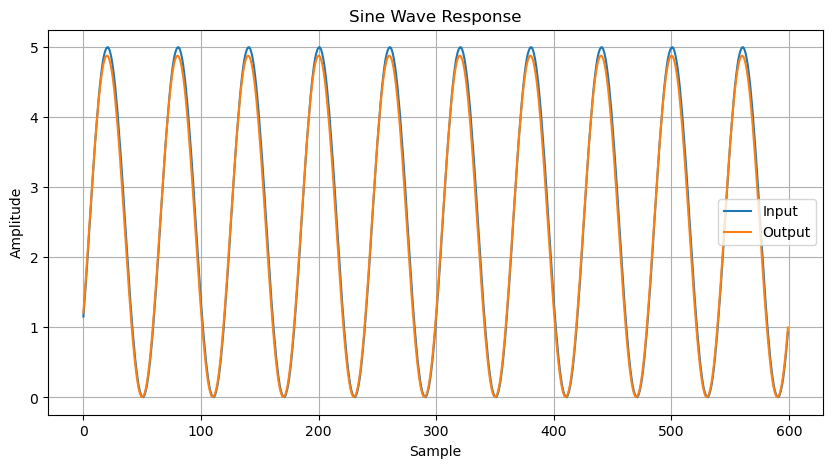

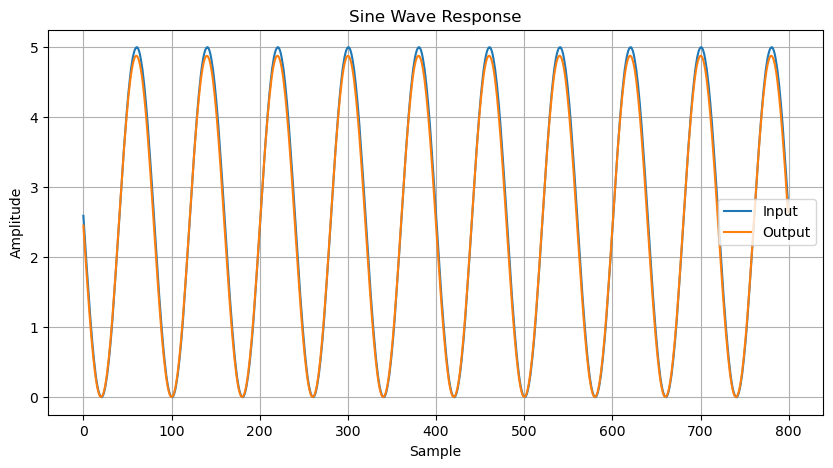

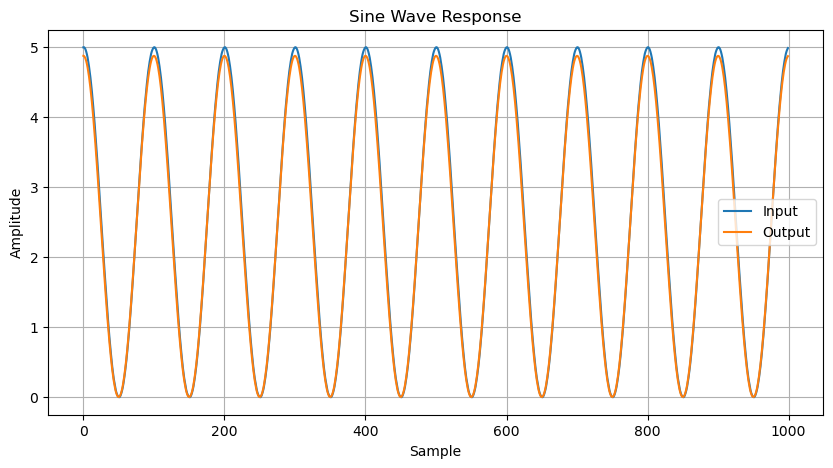

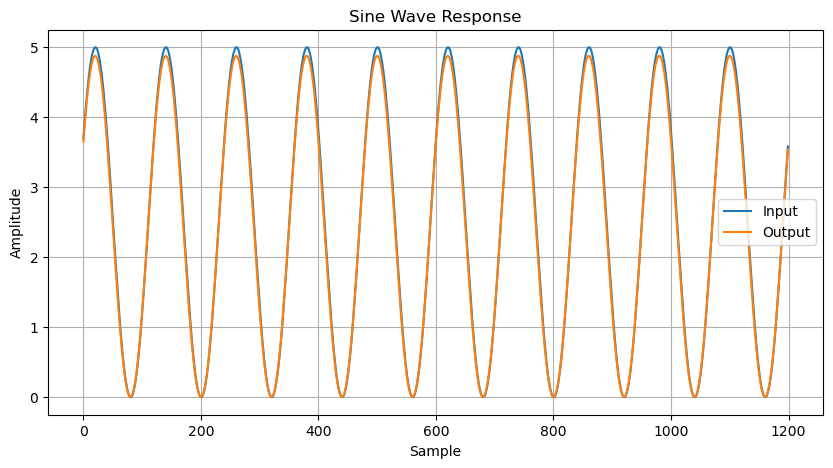

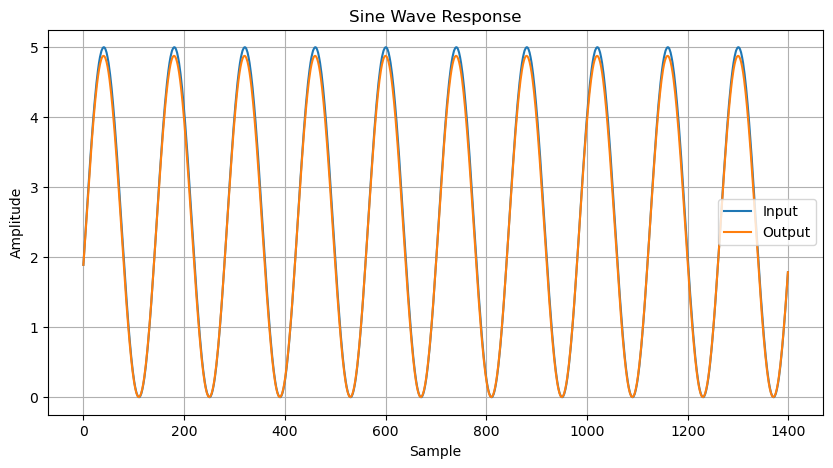

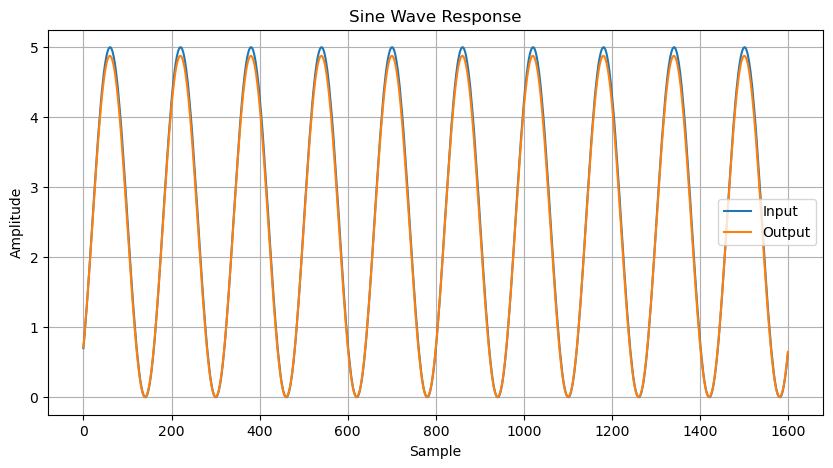

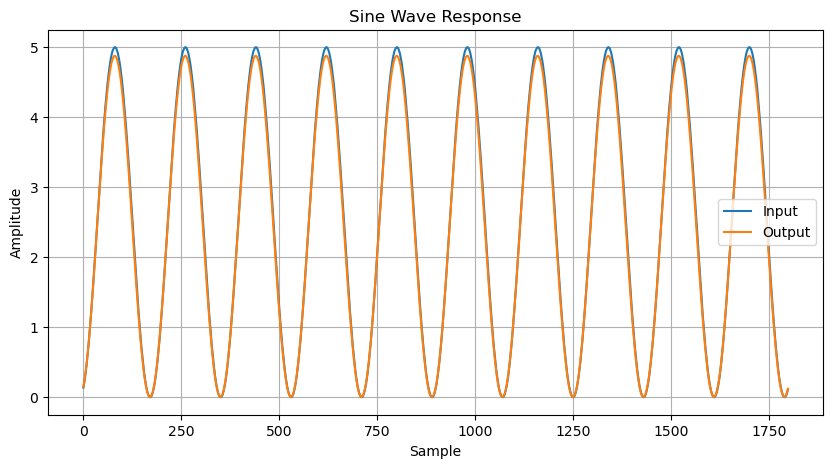

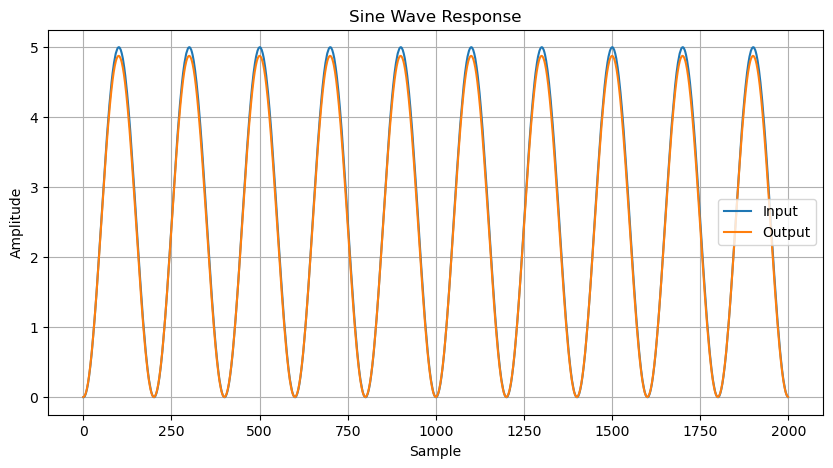

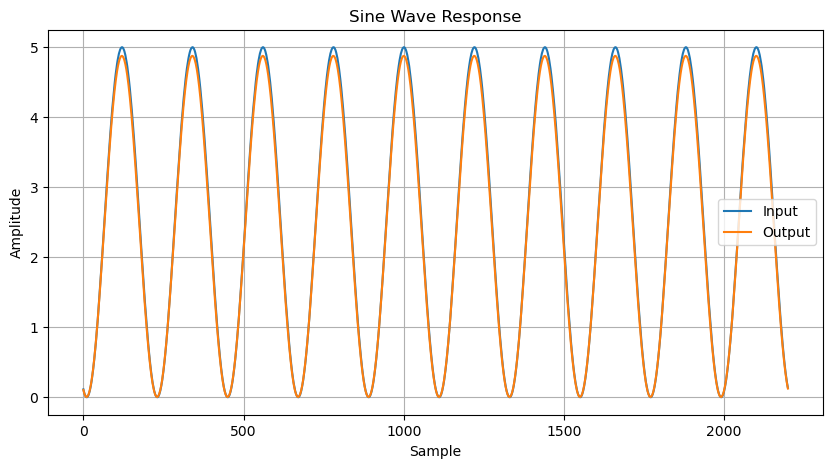

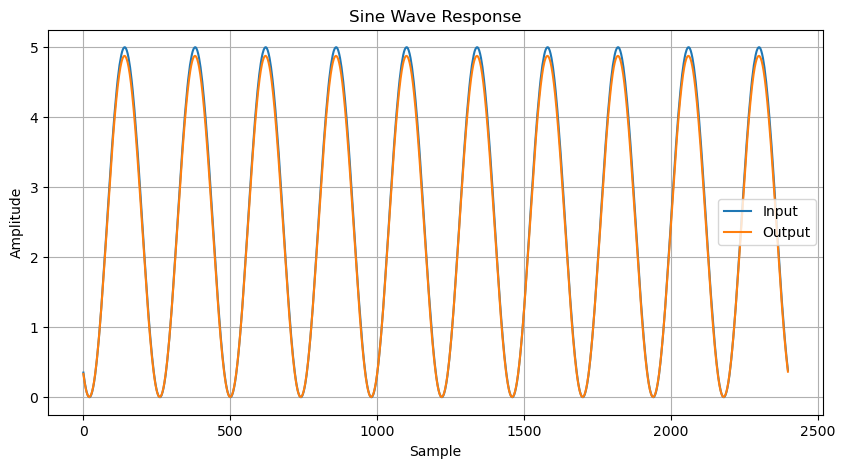

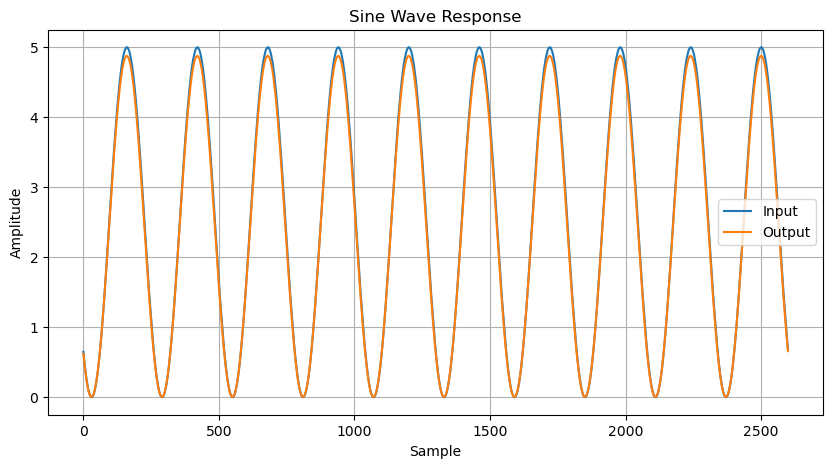

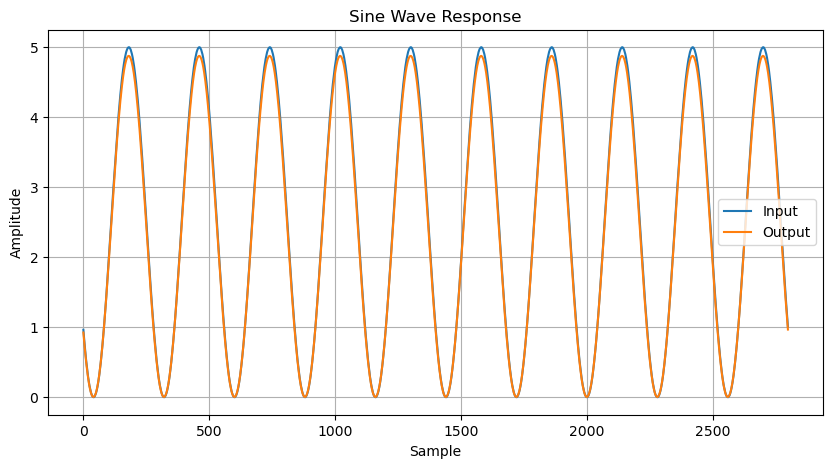

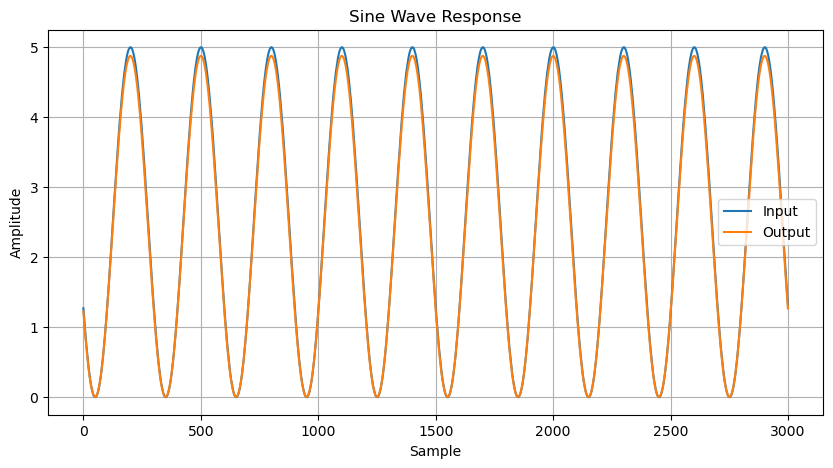

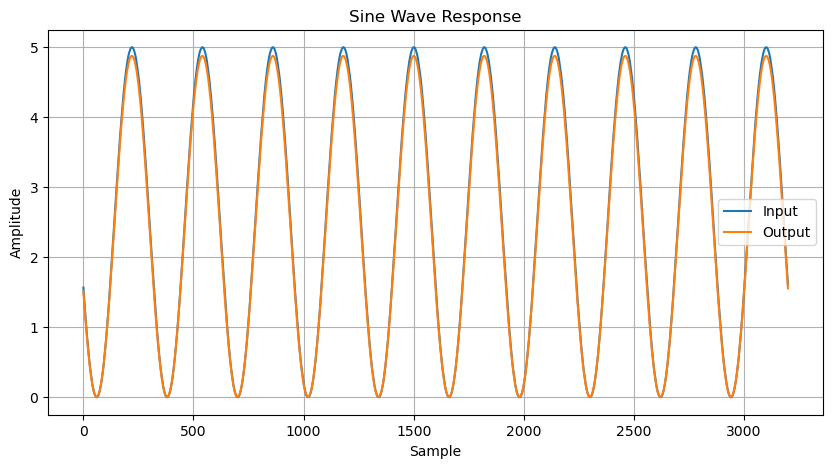

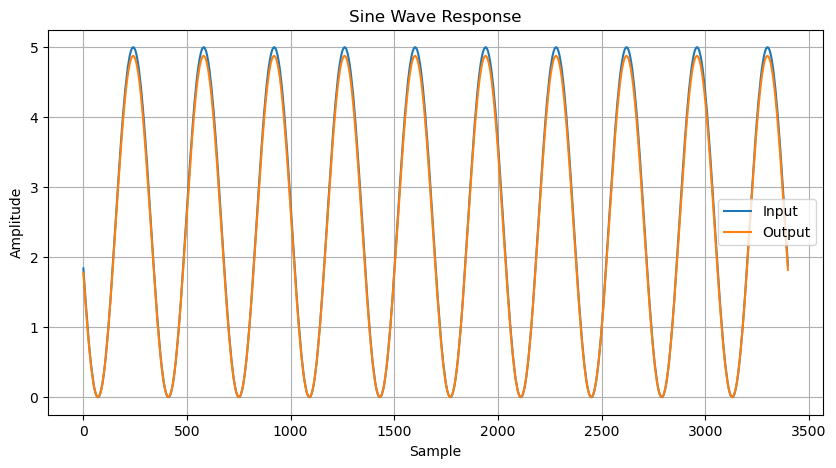

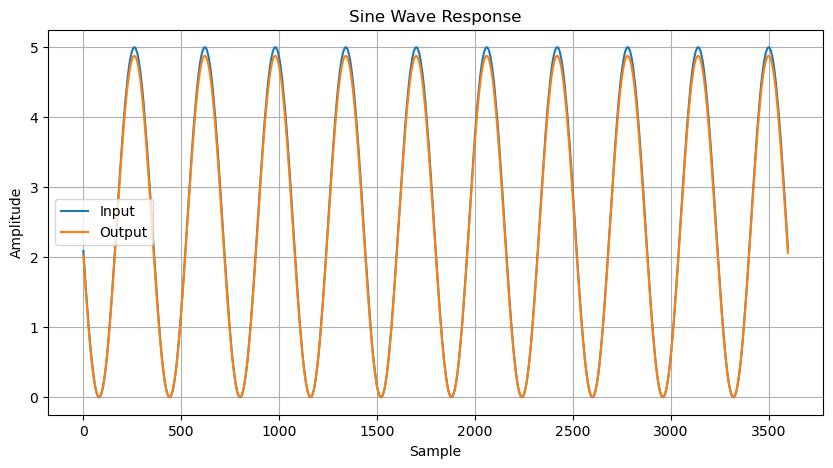

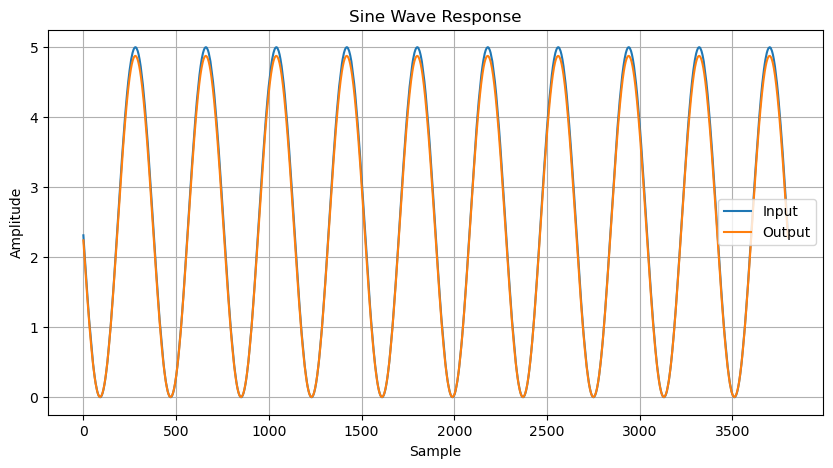

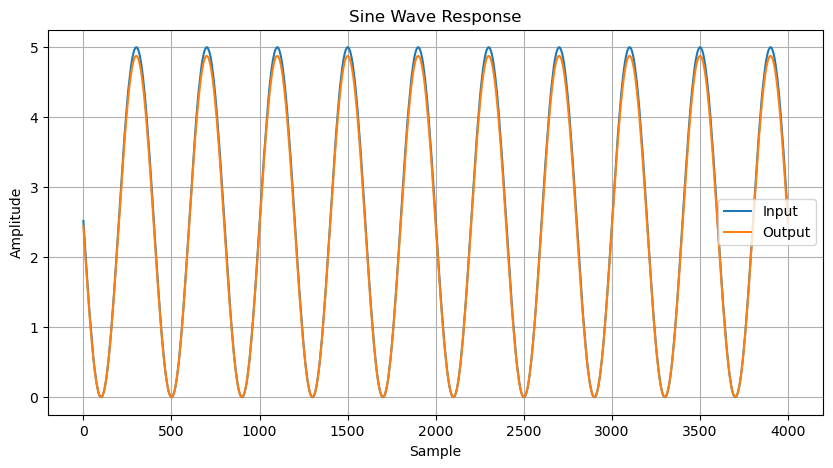

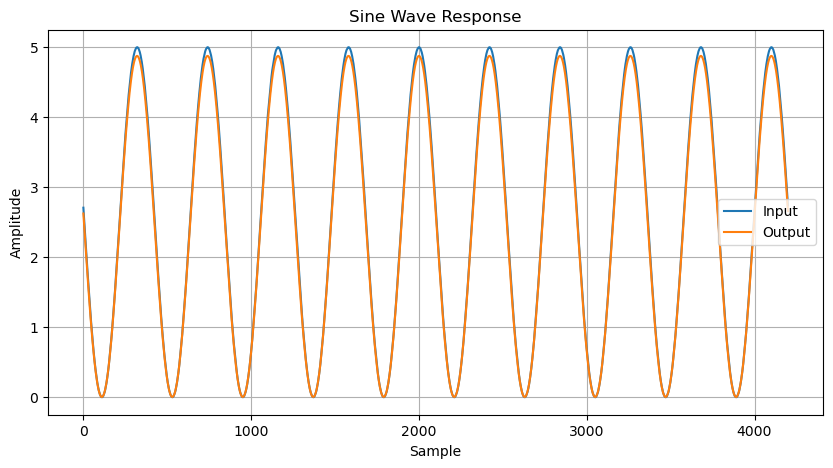

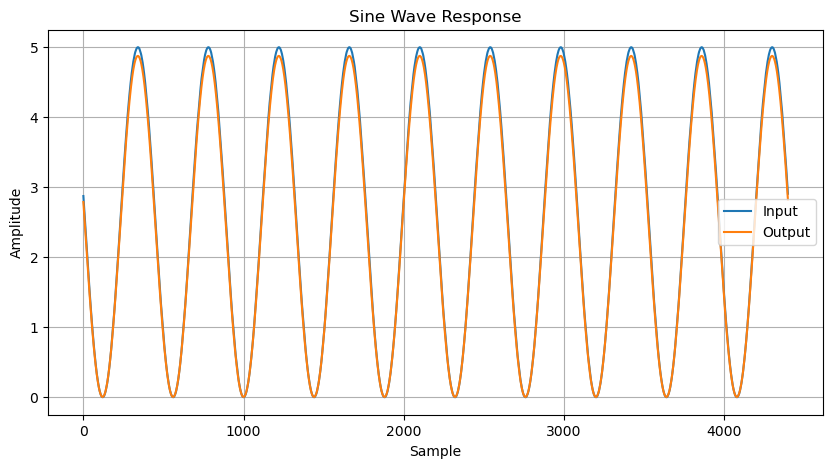

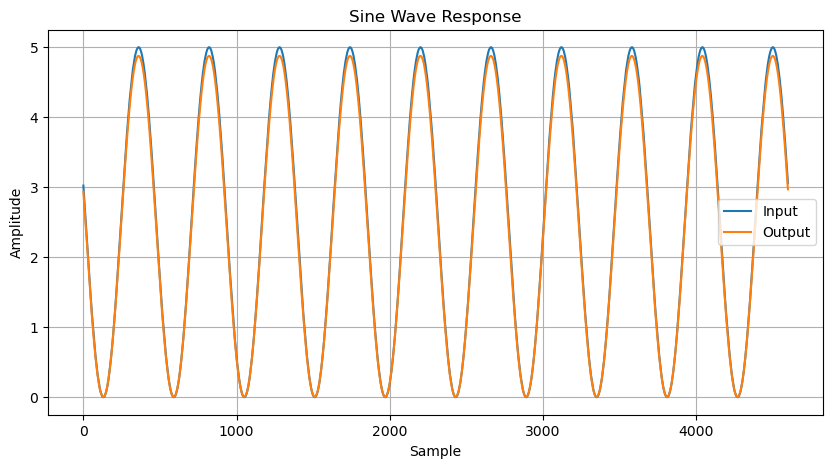

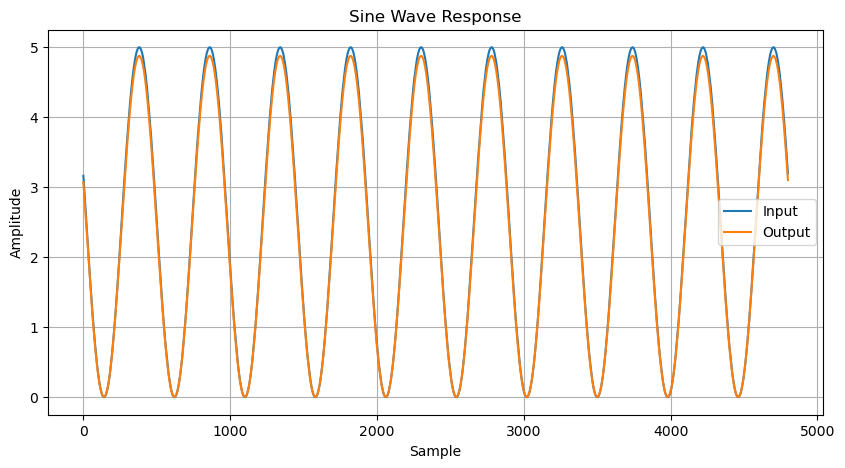

In [12]:
import matplotlib.pyplot as plt
for res in measurement_results:
    inp, out  = res
    plt.figure(figsize=(10, 5))
    plt.plot(inp, label='Input')
    plt.plot(out, label='Output')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.title('Sine Wave Response')
    plt.grid(True)
    plt.legend()
    plt.show()
    

In [16]:
for res,p in zip(measurement_results, ps):
    k=gain_phase(res[0], res[1])
    print(f"Frequency: {k['frequency_cycles_per_sample']:.7f} cycles/sample for set {1/p:.7f} Phase: {k['phase_deg']:.4f} degrees")

Frequency: 0.0500000 cycles/sample for set 0.0500000 Phase: 0.2228 degrees
Frequency: 0.0250000 cycles/sample for set 0.0250000 Phase: -0.0299 degrees
Frequency: 0.0166667 cycles/sample for set 0.0166667 Phase: 0.0303 degrees
Frequency: 0.0125000 cycles/sample for set 0.0125000 Phase: 0.0044 degrees
Frequency: 0.0100000 cycles/sample for set 0.0100000 Phase: -0.0048 degrees
Frequency: 0.0083333 cycles/sample for set 0.0083333 Phase: 0.0092 degrees
Frequency: 0.0071429 cycles/sample for set 0.0071429 Phase: 0.0197 degrees
Frequency: 0.0062500 cycles/sample for set 0.0062500 Phase: 0.0198 degrees
Frequency: 0.0055556 cycles/sample for set 0.0055556 Phase: 0.0067 degrees
Frequency: 0.0050000 cycles/sample for set 0.0050000 Phase: -0.0042 degrees
Frequency: 0.0045455 cycles/sample for set 0.0045455 Phase: 0.0180 degrees
Frequency: 0.0041667 cycles/sample for set 0.0041667 Phase: 0.0145 degrees
Frequency: 0.0038462 cycles/sample for set 0.0038462 Phase: 0.0154 degrees
Frequency: 0.0035714 c

In [ ]:
import time
def measure_gain_phase_at_freqs(s,dev, ps,amp):
    results = []
    for p in ps:
        sine_wave = sig.sine(samples=10*p, midpoint=amp[0], peak=amp[1], period=p, phase=0)
        dev.channels["A"].write(sine_wave,-1)
        time.sleep(1)  # Allow some time for the signal to stabilize
        s.start(10*p+100)
        time.sleep(1)  # Allow some time for the measurement to complete
        data = dev.read(100)
        data = dev.read(10*p)
        list1, list3 = [], []
        for item in data:
            if isinstance(item, tuple):
                (a, b), (c, d) = item
                list1.append(a)
                list3.append(c)
        print(f"Measured {len(list1)} samples for period {p}")
        result = (list1, list3)
        results.append(result)
    return results

In [10]:
for res,p in zip(measurement_results, ps):
    k=gain_phase(res[0], res[1])
    print(f"Frequency: {k['frequency_cycles_per_sample']:.7f} cycles/sample for set {1/p:.7f} Phase: {k['phase_deg']:.4f} degrees")

NameError: name 'measurement_results' is not defined

In [15]:
def gain_phase(inp, out):
    x = np.asarray(inp, dtype=float)
    y = np.asarray(out, dtype=float)

    # Remove DC
    x = x - np.mean(x)
    y = y - np.mean(y)

    N = len(x)

    # FFT
    X = np.fft.rfft(x)
    Y = np.fft.rfft(y)

    # Ignore DC bin
    k = np.argmax(np.abs(X[1:])) + 1

    # Transfer function
    H = Y[k] / X[k]

    mag_linear = np.abs(H)
    mag_db = 20 * np.log10(mag_linear)

    # 1. Get raw phase and frequency
    raw_phase_deg = np.angle(H, deg=True)
    freq_cycles_per_sample = k / N

    # 2. Hardware delay compensation (0.42 samples)
    hardware_delay_samples = 0.42 
    
    # Calculate how many degrees of phase lag this time delay causes at this specific frequency
    phase_error_deg = freq_cycles_per_sample * hardware_delay_samples * 360.0
    
    # 3. Add the error back to advance the phase and correct the hardware lag
    true_phase_deg = raw_phase_deg - phase_error_deg

    # Optional: Keep phase wrapped strictly between -180 and +180
    true_phase_deg = (true_phase_deg + 180) % 360 - 180

    return {
        "frequency_cycles_per_sample": freq_cycles_per_sample,
        "magnitude_linear": mag_linear,
        "magnitude_db": mag_db,
        "phase_deg": true_phase_deg,
        "raw_phase_deg": raw_phase_deg  # Good to keep around for debugging
    }